# Direct Preference Optimization (DPO) Analysis

$$\mathcal{L}_{\text{DPO}}(\pi_\theta; \pi_{\text{ref}}) = -\mathbb{E}_{(x, a^{+}, a^{-}) \sim \mathcal{D}} \left[ \log \sigma \left( \beta \log \frac{\pi_\theta(a^{+} \mid x)}{\pi_{\text{ref}}(a^{+} \mid x)} - \beta \log \frac{\pi_\theta(a^{-} \mid x)}{\pi_{\text{ref}}(a^{-} \mid x)} \right) \right]$$

We need:
1. A **policy model** $\pi_\theta$
2. A frozen **reference model** $\pi_{\text{ref}}$
3. The **DPO loss function**
4. A **training loop** that handles both models

#### Run this ONLY if you're inside Google Collab

In [ ]:
!apt-get -qq update
!apt-get -qq install -y ffmpeg
!git clone https://github.com/pedropintoo/RL-project.git /content/RL-project

!pip install stable_baselines3

%cd /contenRLprdgiontent/RL-project/dpo
!git pull origin main

import sys
sys.path.append("/content/RL-project/dpo")

E: Could not open lock file /var/lib/apt/lists/lock - open (13: Permission denied)
E: Unable to lock directory /var/lib/apt/lists/
W: Problem unlinking the file /var/cache/apt/pkgcache.bin - RemoveCaches (13: Permission denied)
W: Problem unlinking the file /var/cache/apt/srcpkgcache.bin - RemoveCaches (13: Permission denied)
E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
fatal: could not create leading directories of '/content/RL-project': Permission denied
[Errno 2] No such file or directory: '/content/RL-project/dpo'
/home/pedro/Documents/Universidade/4ano/2semestre/RL/RL-project/dpo


/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


### Import the Necessary Packages

In [41]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from collections import deque
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import copy
import os
import sys
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

from stable_baselines3 import PPO

from pathlib import Path

from utils import load_preference_dataset, preference_pair_logps, show_video_of_model, show_video, evaluate_policy_returns

from policy import DiscretePolicy, ContinuousPolicy, SB3DiscretePolicyAdapter, SB3ContinuousPolicyAdapter

In [42]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

### The DPO Loss Function

$$\mathcal{L}_{\text{DPO}} = -\log \sigma\left( \beta \cdot \left[ \left(\log \pi_\theta(a^{+}|x) - \log \pi_{\text{ref}}(a^{+}|x)\right) - \left(\log \pi_\theta(a^{-}|x) - \log \pi_{\text{ref}}(a^{-}|x)\right) \right] \right)$$

In [ ]:
from dpo_experiments import run_dpo_scaling_experiment
from dpo_plotting import plot_environment_results
from config import ENVIRONMENTS

print(f'Using module dir: {module_dir}')
print(f'Using data_generation dir: {DATA_GEN_DIR}')

### Scaling Experiment (Modular Version)

This section mirrors the RLHF protocol:

- Dataset sizes: $K \in \{50, 200, 1000\}$
- Seeds: $\{1,2,3,4,5\}$
- Train one DPO model per $(K, \text{seed})$
- Aggregate return statistics across seeds
- Plot scaling curves with the same style used in `rlhf/plot_results.py`

In [44]:
K_VALUES = [50, 200, 1000]
SEEDS = [1, 2, 3, 4, 5]
ENV_IDS = [cfg.env_id for cfg in ENVIRONMENTS]

PREFERENCE_DIR = Path("../data_generation/outputs/preferences")
POLICY_DIR = Path("../data_generation/outputs/policies")

DPO_OUTPUT_DIR = Path("./outputs/dpo_scaling")
PLOT_DIR = DPO_OUTPUT_DIR / "plots"
DPO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Main sweep hyperparameters
N_EPOCHS = 1
LEARNING_RATE = 1e-4
BETA = 0.1
PLATEAU_WINDOW = 12
N_EVAL_EPISODES = 50


### Load Preference Dataset

$$(x, a^{+}, a^{-}) \sim \mathcal{D}$$

In [45]:
all_results = {}

for env_id in ENV_IDS:
    print(f"\n================ {env_id} ================")
    env_results = run_dpo_scaling_experiment(
        env_id=env_id,
        dataset_sizes=K_VALUES,
        seeds=SEEDS,
        preference_dir=PREFERENCE_DIR,
        policy_dir=POLICY_DIR,
        output_dir=DPO_OUTPUT_DIR,
        device=device,
        n_epochs=N_EPOCHS,
        lr=LEARNING_RATE,
        beta=BETA,
        early_stop=True,
        plateau_window=PLATEAU_WINDOW,
        n_eval_episodes=N_EVAL_EPISODES,
    )
    all_results.update(env_results)

results_file = DPO_OUTPUT_DIR / "dpo_scaling_all_envs.json"
with results_file.open("w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2)

print(f"\nSaved merged results to {results_file}")

/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



================ CartPole-v1 ================
Evaluating baselines for CartPole-v1...



=== DPO | env=CartPole-v1 | K=50 ===
Training DPO for K=50, seed=1...
Epoch 1	Average Loss: 0.5595	Best: 0.5595 (epoch 1)
Restored best checkpoint from epoch 1 with loss 0.5595.
Training DPO for K=50, seed=2...
Epoch 1	Average Loss: 0.5575	Best: 0.5575 (epoch 1)
Restored best checkpoint from epoch 1 with loss 0.5575.
Training DPO for K=50, seed=3...
Epoch 1	Average Loss: 0.5592	Best: 0.5592 (epoch 1)
Restored best checkpoint from epoch 1 with loss 0.5592.
Training DPO for K=50, seed=4...
Epoch 1	Average Loss: 0.5587	Best: 0.5587 (epoch 1)
Restored best checkpoint from epoch 1 with loss 0.5587.
Training DPO for K=50, seed=5...
Epoch 1	Average Loss: 0.5573	Best: 0.5573 (epoch 1)
Restored best checkpoint from epoch 1 with loss 0.5573.

=== DPO | env=CartPole-v1 | K=200 ===
Training DPO for K=200, seed=1...
Epoch 1	Average Loss: 0.2575	Best: 0.2575 (epoch 1)
Restored best checkpoint from epoch 1 with loss 0.2575.
Training DPO for K=200, seed=2...
Epoch 1	Average Loss: 0.2577	Best: 0.2577 

### Policy Model + Reference Model

In [46]:
import pandas as pd

rows = []
for env_id, env_data in all_results.items():
    rows.append({
        "env": env_id,
        "method": "expert",
        "K": "-",
        "mean": env_data["baselines"]["expert"]["mean"],
        "std": env_data["baselines"]["expert"]["std"],
    })
    rows.append({
        "env": env_id,
        "method": "mid",
        "K": "-",
        "mean": env_data["baselines"]["mid"]["mean"],
        "std": env_data["baselines"]["mid"]["std"],
    })

    for k in sorted(env_data["dpo"].keys(), key=int):
        rows.append({
            "env": env_id,
            "method": "dpo",
            "K": int(k),
            "mean": env_data["dpo"][k]["mean"],
            "std": env_data["dpo"][k]["std"],
        })

summary_df = pd.DataFrame(rows).sort_values(["env", "method", "K"], na_position="last")
summary_df

,env,method,K,mean,std
2,CartPole-v1,dpo,50,87.564000,3.058925
3,CartPole-v1,dpo,200,89.880000,3.217403
4,CartPole-v1,dpo,1000,110.832000,3.649605
0,CartPole-v1,expert,-,500.000000,0.000000
1,CartPole-v1,mid,-,336.620000,200.303958
7,Pendulum-v1,dpo,50,-869.347618,30.864832
8,Pendulum-v1,dpo,200,-1069.776538,49.945277
9,Pendulum-v1,dpo,1000,-1123.152558,11.570977
5,Pendulum-v1,expert,-,-275.359714,294.574813
6,Pendulum-v1,mid,-,-668.018614,126.032294


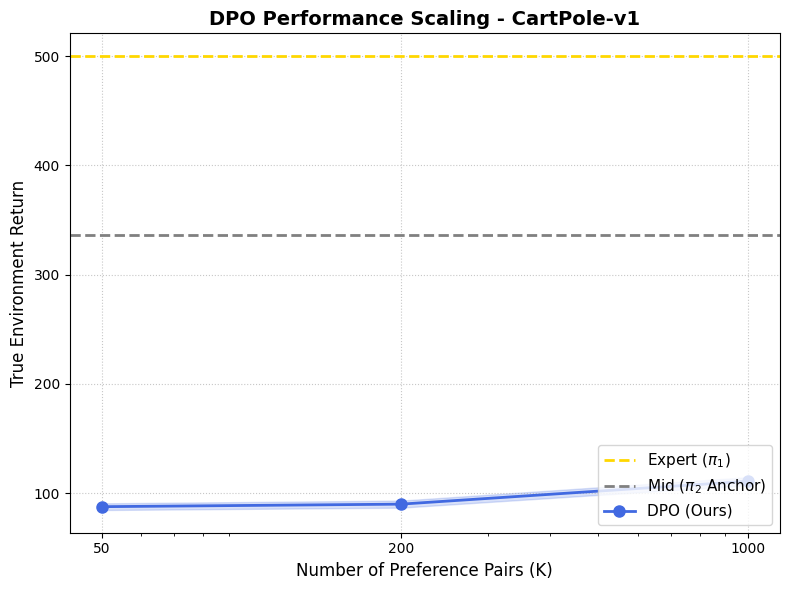

Saved plot to outputs/dpo_scaling/plots/CartPole-v1_scaling_plot.png


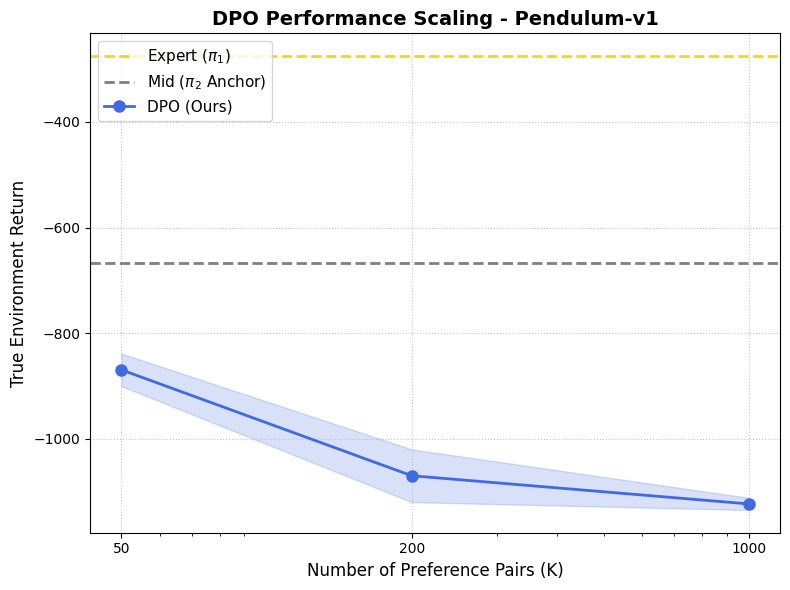

Saved plot to outputs/dpo_scaling/plots/Pendulum-v1_scaling_plot.png


In [47]:
for env_id, env_data in all_results.items():
    plot_path = plot_environment_results(env_id, env_data, PLOT_DIR)
    print(f"Saved plot to {plot_path}")

In [48]:
for env_id, env_data in all_results.items():
    print(f"\n{env_id} raw returns by K and seed:")
    for k in sorted(env_data["dpo"].keys(), key=int):
        print(f"  K={k}: {env_data['dpo'][k]['raw_seeds']}")


CartPole-v1 raw returns by K and seed:
  K=50: [87.76, 85.68, 93.34, 86.38, 84.66]
  K=200: [91.8, 95.1, 85.94, 88.58, 87.98]
  K=1000: [116.34, 109.82, 112.46, 110.4, 105.14]

Pendulum-v1 raw returns by K and seed:
  K=50: [-899.7290200536492, -842.9954571553078, -827.2703148664372, -870.3245380410398, -906.4187595392448]
  K=200: [-1108.1510252557662, -1083.9946957484635, -1056.9146328085264, -1120.0652896771605, -979.7570448988617]
  K=1000: [-1133.964780122798, -1132.0759909341684, -1119.11221189217, -1102.3934754653328, -1128.2163317092338]


In [49]:
np.bool8 = np.bool
save_path = './demos/'
Path(save_path).mkdir(parents=True, exist_ok=True)
names = ['p_expert', 'p_mid', 'policy_model']

for i, policy in enumerate([p_expert, p_mid, policy_model]):
    file = save_path + names[i]
    print(f"Showing video for {names[i]}...")
    # create video
    show_video_of_model(file, policy, 'Pendulum-v1')

    # show video
    show_video(file, 'Pendulum-v1')

Showing video for p_expert...


/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment Pendulum-v1 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
/home/pedro/miniconda3/envs

Showing video for p_mid...


/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment Pendulum-v1 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
/home/pedro/miniconda3/envs

Showing video for policy_model...


/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment Pendulum-v1 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
/home/pedro/miniconda3/envs

In [50]:
# Optional: export summary table
summary_csv = DPO_OUTPUT_DIR / "dpo_scaling_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"Saved table to {summary_csv}")

Saved table to outputs/dpo_scaling/dpo_scaling_summary.csv
